# NCAA tournament forecasting: verified release
**Alvaro Mendizabal · evidence-led ML engineering**

This executable public review reconstructs the score comparison, checks disclosed evidence hashes, and preserves the complete historical cohort. It does not train or disclose the private forecasting recipe.

In [1]:
from pathlib import Path
import json, sys
root = Path.cwd()
if not (root / 'portfolio').is_dir(): root = root.parent
sys.path.insert(0, str(root / 'portfolio'))
from reproduce_release import write_report
result = write_report(root)
print(json.dumps({key: result[key] for key in [
    'accepted_submission_id', 'submission_rows', 'accepted_brier',
    'reference_brier', 'absolute_brier_reduction',
    'relative_brier_reduction_percent_display']}, indent=2))

{
  "accepted_submission_id": "56928396",
  "submission_rows": 132133,
  "accepted_brier": "0.1067095",
  "reference_brier": "0.1097454",
  "absolute_brier_reduction": "0.0030359",
  "relative_brier_reduction_percent_display": "2.7663"
}


## Size of the observed improvement
The comparison uses exact decimal inputs and reports both absolute and relative Brier reduction. Lower Brier means lower mean squared probability error on the scored games. The measured reduction is useful evidence of progress; score arithmetic alone does not establish statistical significance or isolate a causal contribution from any single technique.

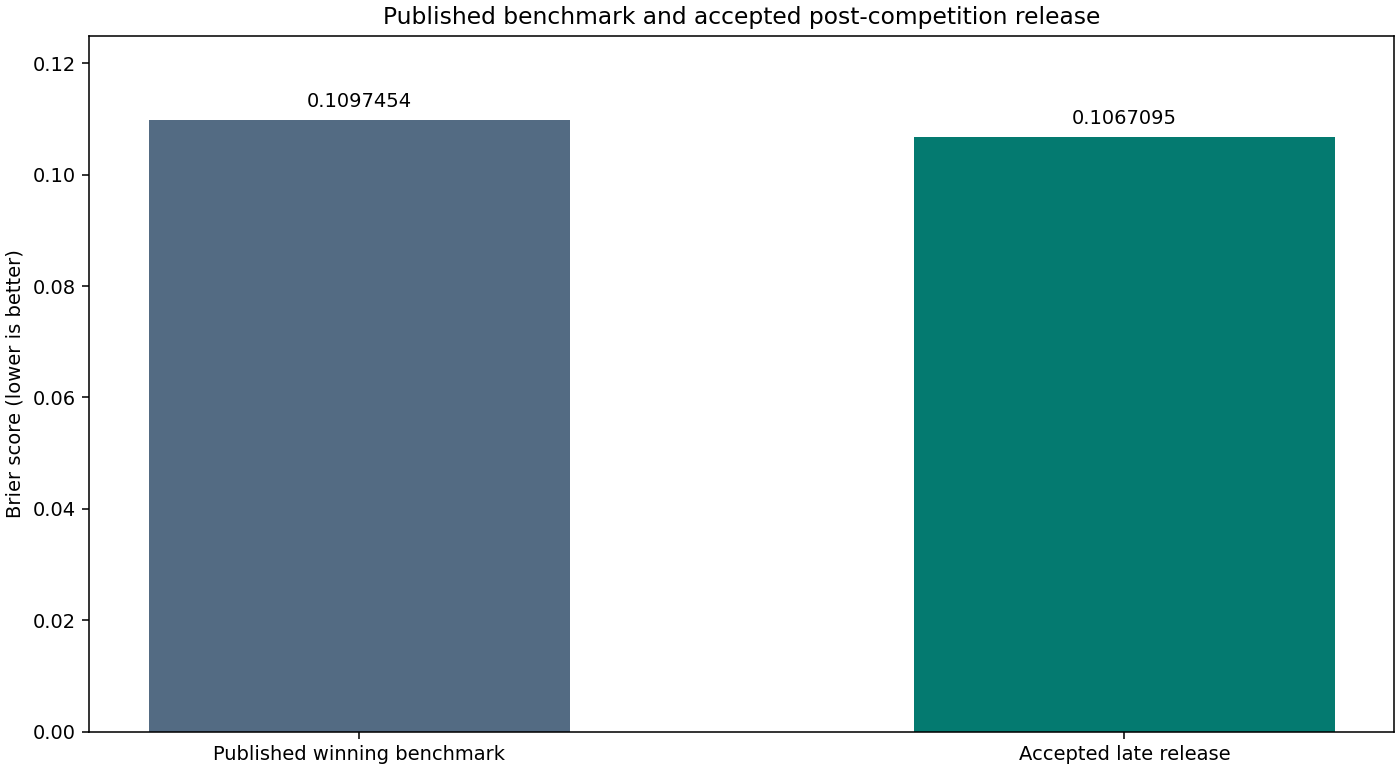

In [2]:
import base64, io
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
labels = ['Published winning benchmark', 'Accepted late release']
values = [float(result['reference_brier']), float(result['accepted_brier'])]
colors = ['#536b83', '#047a70']
figure = go.Figure(go.Bar(x=labels, y=values, marker_color=colors,
    text=[f'{value:.7f}' for value in values], textposition='outside'))
figure.update_layout(title='Brier score comparison — lower is better',
    width=960, height=530, yaxis_range=[0, 0.125],
    yaxis_title='Brier score', template='plotly_white', font_size=16)
static, axis = plt.subplots(figsize=(10, 5.5), layout='constrained')
bars = axis.bar(labels, values, color=colors, width=0.55)
axis.bar_label(bars, labels=[f'{value:.7f}' for value in values], padding=5)
axis.set_ylim(0, 0.125)
axis.set_ylabel('Brier score (lower is better)')
axis.set_title('Published benchmark and accepted post-competition release')
stream = io.BytesIO()
static.savefig(stream, format='png', dpi=140)
plt.close(static)
png_path = root / 'reports/verified_result/score_comparison.png'
png_path.write_bytes(stream.getvalue())
display({'application/vnd.plotly.v1+json': json.loads(figure.to_json()),
    'image/png': base64.b64encode(stream.getvalue()).decode()}, raw=True)

## Complete cohort, separate eligibility histories
All historical games remain visible, including unavailable-source cases. Legacy source eligibility and the prior player-model eligibility are distinct masks; neither is represented as a newly untouched validation set. These are aggregate retained counts, not a reconstruction of private per-game outcomes.

In [3]:
coverage = result['historical_coverage']
print(json.dumps(coverage, indent=2))
assert (coverage['legacy_eligible'] + coverage['legacy_ineligible']
        == coverage['games'])
assert (coverage['prior_v81_eligible'] + coverage['prior_v81_ineligible']
        == coverage['games'])
print('Every game is retained; eligibility masks remain separately identified.')

{
  "games": 566,
  "legacy_eligible": 541,
  "legacy_ineligible": 25,
  "prior_v81_eligible": 418,
  "prior_v81_ineligible": 148,
  "consumed": true
}
Every game is retained; eligibility masks remain separately identified.


## Separate matched reconstruction
The 126-game matched audit is a different comparison from the published winning score above. Its reference is a reconstruction of the reference method on 63 men's and 63 women's games. Keeping the two denominators separate prevents conflating an official leaderboard score with a locally reconstructed method. The aggregate change is concentrated in the men's forecasts; the women's probabilities were reconciled to the reference. These outcomes had already been inspected.

In [4]:
print(json.dumps(result['matched_reconstruction'], indent=2))

{
  "evaluation_games": 126,
  "men_games": 63,
  "women_games": 63,
  "reference_method_brier": "0.10991210500176371",
  "project_brier": "0.10670955428085621",
  "absolute_brier_reduction": "0.00320255072090750",
  "relative_brier_reduction_percent": "2.913737955301747803218351194183623012363",
  "relative_brier_reduction_percent_display": "2.9137",
  "source_audit_sha256": "680438e18b4d496e506f4c3e11021c2207fcc63706705da2d71ee959a4639413",
  "fresh_holdout": false
}


## Evidence integrity and limits
The verifier checks the SHA-256 of each disclosed evidence document. Those hashes demonstrate consistency with this release, not independent authentication by Kaggle. The acceptance receipt is an owner-supplied aggregate, and the reference links to the published competition result.

The accepted result was produced after the competition. It is numerically below the published winning score, but it is not an original competition placement or a prospective 2027 result. Consumed historical outcomes and post-competition research limit generalization claims.

In [5]:
print(json.dumps(result['source_documents_verified'], indent=2))
print('Evidence SHA-256:', result['evidence_sha256'])
print('Private model reproduced:', result['private_model_reproduced'])
print('Model fits:', result['model_fits'])
print('Network requests:', result['network_requests'])
print('VERIFIED_PUBLIC_REVIEW_COMPLETE')

[
  {
    "path": "reports/verified_result/submission_receipt.json",
    "sha256": "ae23fff360ed6bb9efc9dab404800a6502421d02bcee4b212c5a4ae390e91d36"
  }
]
Evidence SHA-256: fbb55faf4df04c39bf9bb247ecbf3bbfe080151c1d3fd1a5c58afff40c0b38e9
Private model reproduced: False
Model fits: 0
Network requests: 0
VERIFIED_PUBLIC_REVIEW_COMPLETE


## Public reproduction boundary
The repository includes runnable public baseline and review code. This notebook is the compact verification path for the latest accepted release. Private predictions, model binaries, exact blend choices, and the current private feature recipe are intentionally excluded. A credible next generalization claim requires timestamped source inputs and frozen predictions recorded before future tournament outcomes.